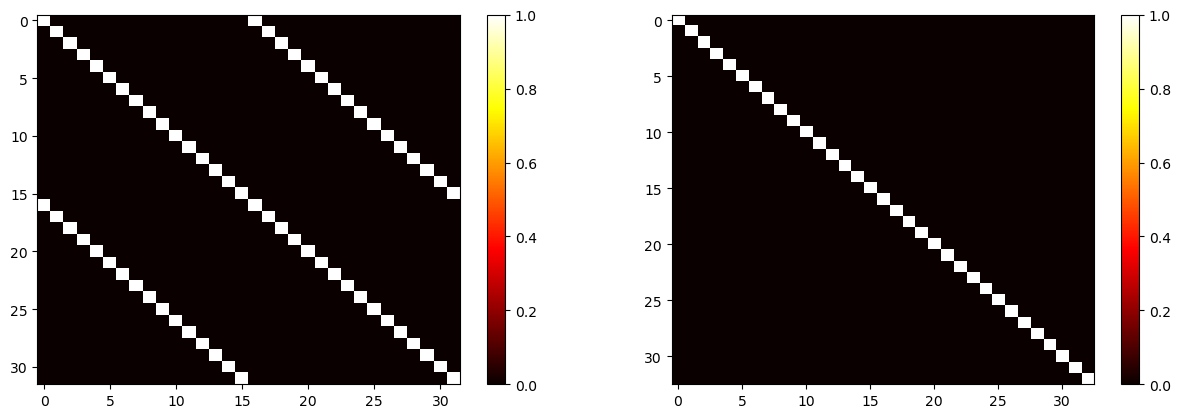

In [3]:
import numpy as np
from numpy.fft import fft, ifft, fftfreq, rfft, irfft, rfftfreq
import matplotlib.pyplot as plt
import emcee
import corner

def Cnm(n,m):
    return np.exp((1j*np.pi/4)*(1-(-1)**(n+m)))

'''
def Phi_unit(l,DT,nt,A=1/3):
    B = 1.0 - 2.0 * A
    T = nt*DT
    df = 1.0 / T
    f = l * df
    DF = 1.0 / (2.0 * DT)
    return np.where(np.abs(f/DF)>A+B,f*0,np.where(np.abs(f/DF)>A,np.cos((np.pi/2)*(np.abs(f/DF)-A)/B),f*0+1))/np.sqrt(nt/2)
'''
def Phi_unit(l,nt,A=1/3):
    B = 1.0 - 2.0 * A
    lres = l*2/nt
    return np.where(np.abs(lres)>A+B,lres*0,np.where(np.abs(lres)>A,np.cos((np.pi/2)*(np.abs(lres)-A)/B),lres*0+1))/np.sqrt(nt/2)

def gnmf(n,m,l,nt,nf):
    '''Returns the Gabor atom g_{n,m}(f) in frequency domain, sampled at frequencies f, for time shift n and freq shift m.'''

    return np.where(m==0,np.exp(-4j*np.pi*n*l/nt)*Phi_unit(l,nt),
             np.where(m==nf,(Phi_unit(l+m*nt/2,nt)+Phi_unit(l-m*nt/2,nt))*np.exp(-4j*np.pi*n*l/nt),
                    (np.conjugate(Cnm(n,m))*Phi_unit(l+m*nt/2,nt)+Cnm(n,m)*Phi_unit(l-m*nt/2,nt))
                     *np.exp(-2j*np.pi*n*l/nt)/np.sqrt(2)
             ))

def wdm_forward(x, nt, nf):
    ''' Forward WDM: from time-domain signal x of length nt*nf to W of shape (nt, nf+1) '''

    n_total = nt * nf
    if nt % 2 != 0 or nf % 2 != 0:
        raise ValueError("nt and nf must both be even.")
    if x.shape[-1] != n_total:
        raise ValueError(f"len(x)={x.shape[-1]} must equal nt*nf={n_total}.")

    # 1) Compute FFT of full signal
    X_fft = fft(x)  # length = n_total

    # 2) Build φ-window of length=nt
    half = nt // 2
    phi_window = Phi_unit(fftfreq(nt)*nt,nt)  # length = nt

    # 3) Prepare output array
    W = np.zeros((nt, nf+1), dtype=float)

    # 4) Handle m=0 separately, since they only involve half of the φ-window
    block=X_fft[1:half]*phi_window[1:half]
    l_arr=np.arange(1,half)
    narr=np.arange(nt)
    W[:, 0] = np.real(np.sum(np.exp(4j*np.pi*l_arr[None,:]*narr[:,None]/nt)*block[None,:],axis=1)
                      +X_fft[0]*phi_window[0]/2)

    # 5) For each sub-band m=1..nf-1:
    for m in range(1, nf):
        block = np.concatenate([X_fft[int(m*half):int((m+1)*half)], X_fft[int((m-1)*half):int(m*half)]])
        
        # Multiply by φ-window and IFFT
        xnm_time = ifft(block * phi_window) * nt # length = nt, complex

        # Real part of conj(C)·xnm_time, scaled by √2/nf
        W[:, m] = (-1)**(m*np.arange(nt))*(np.sqrt(2.0)) * np.real(np.conj(Cnm(np.arange(nt), m)) * xnm_time)

    # 6) Handle m=nf separately, since they only involve the other half of the φ-window
    block=X_fft[n_total//2-half:n_total//2]*phi_window[-half:]
    l_arr=np.arange(n_total//2-half,n_total//2)
    narr=np.arange(nt)
    W[:, nf] = np.real(np.sum(np.exp(4j*np.pi*l_arr[None,:]*narr[:,None]/nt)*block[None,:],axis=1)
                       +np.conjugate(X_fft[n_total//2])*phi_window[0]/2)

    return W

''' Parameters for our example '''

Ntry=1024
nttry=32
dttry=0.1
nftry=int(Ntry//nttry)
DTtry=nftry*dttry

larr=fftfreq(Ntry)*Ntry

times=np.arange(Ntry)*dttry
Ttry=Ntry*dttry
freqs=larr/Ttry
idx = np.argsort(freqs)

''' Checks on the orthonormality conditions for the g_nm basis elements '''

# Uncomment the following to check that phi is normalized to 1
# print(np.sum(Phi_unit(larr,nttry)**2))

# Precompute a table of gnm elements
gnmf_tab = np.zeros((nttry,nftry+1,Ntry))*1j
for n in range(nttry):
    for m in range(nftry+1):
        gnmf_tab[n,m] = gnmf(n,m,larr,nttry,nftry)

# Plot of the orthogonality relation g_nm * conj(g_n'm) = delta_nn'
nnpmat=np.zeros((nttry,nttry))*1j
mym=0 # picked fixed value of m, you can change it
for n in range(nttry):
    for n2 in range(nttry):
        nnpmat[n,n2]=np.sum(gnmf(n,mym,larr,nttry,nftry)*np.conjugate(gnmf(n2,mym,larr,nttry,nftry)))


# Plot of the orthogonality relation g_nm * conj(g_nm') = delta_mm'
mmpmat=np.zeros((nftry+1,nftry+1))*1j
myn=5 # picked fixed value of n, you can change it
for m in range(nftry+1):
    for m2 in range(nftry+1):
        mmpmat[m,m2]=np.sum(gnmf(myn,m,larr,nttry,nftry)*np.conjugate(gnmf(myn,m2,larr,nttry,nftry)))

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(15)
im1=ax1.imshow(np.abs(nnpmat), cmap='hot', aspect='auto')
im2=ax2.imshow(np.abs(mmpmat), cmap='hot', aspect='auto')
fig.colorbar(im1, ax=ax1)
fig.colorbar(im2, ax=ax2)
plt.show()

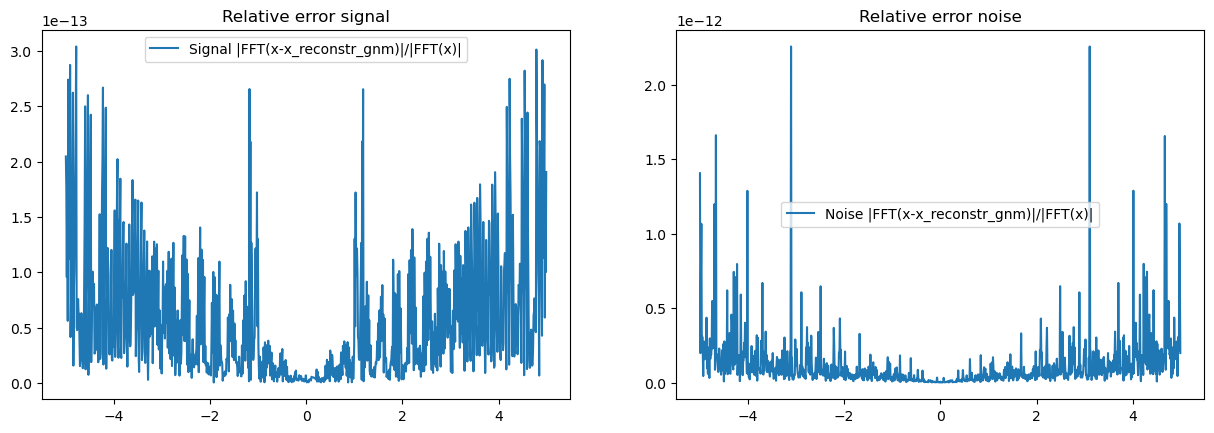

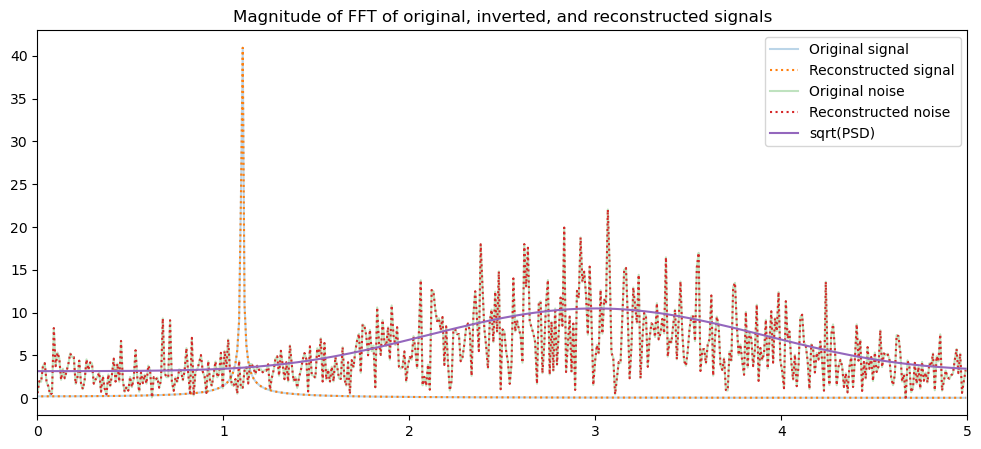

SNR t domain 0.3470640287010303
SNR f domain 0.3470640287010303
SNR wdm domain 0.34770691389681874

SNR t opt 11.106103151931414
SNR f opt 11.10746343424822
SNR w opt 11.30357188065005


In [2]:
'''
Example: sinusoid + stationary noise
1) Data generation and checks of frequency->wdm->frequency transforms
2) Computation of SNR in time, frequency, wdm domains
3) Parameter inference on amplitude, frequency and phase of the sinusoidal signal

'''
def sinusoid_t(A,f0,phi,N,dt): # Generate signal at our sampled times
    t = np.arange(N) * dt
    return A * np.sin(2 * np.pi * f0 * t + phi)

def dirichlet(l,N):
    return np.sin(np.pi*l)/np.sin(np.pi*l/N)

def sinusoid_f(A,f0,phi,N,dt):
    l=fftfreq(N)*N
    l0=f0*N*dt
    exp1=np.exp(1j*phi+1j*np.pi*(l0-l)*(N-1)/N)
    exp2=np.exp(-1j*phi-1j*np.pi*(l0+l)*(N-1)/N)
    return (A/2j)*(exp1*dirichlet(l0-l,N)-exp2*dirichlet(l0+l,N))

def PSD_noise(f): # PSD of a stationary noise in frequency domain (constant+gaussian, it can be changed)
    return 10+100*np.exp(-(np.abs(f)-3)**2)

def random_signal_f(PSD_func,ntotal,dt): # Generates the noise in time domain from a PSD with given number of samples and cadence
    freqs = rfftfreq(ntotal,dt)
    noise_filtered = np.sqrt(PSD_func(freqs))*(np.random.normal(size=len(freqs))+1j*np.random.normal(size=len(freqs)))/np.sqrt(2)
    return irfft(noise_filtered)

# Parameters of the sinusoid
Atest=0.1
f0test=1.1
phitest=0.5

# The sinusoid in all domains
xsin=sinusoid_t(Atest,f0test,phitest,Ntry,dttry)
xsin_f=fft(xsin)
xsin_wnm=wdm_forward(xsin, nttry, nftry)

# The noise in all domains
xrand=random_signal_f(PSD_noise,Ntry,dttry)
xrand_f=fft(xrand)
xrand_wnm = wdm_forward(xrand, nttry, nftry)

# The reconstructed frequency domain for signal and noise from x_f=sum_nm g_nm(f) w_nm
xsin_f_reconstr= np.einsum('nm,nmk->k', xsin_wnm, gnmf_tab)
xrand_f_reconstr= np.einsum('nm,nmk->k', xrand_wnm, gnmf_tab)

# Checks that the error between reconstructed and original signal is small for both sinusoid and noise
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(15)
ax1.plot(freqs[idx],np.abs(xsin_f[idx]-xsin_f_reconstr[idx])/np.abs(xsin_f[idx]),label='Signal |FFT(x-x_reconstr_gnm)|/|FFT(x)|')
ax2.plot(freqs[idx],np.abs(xrand_f[idx]-xrand_f_reconstr[idx])/np.abs(xrand_f[idx]),label='Noise |FFT(x-x_reconstr_gnm)|/|FFT(x)|')
ax1.legend()
ax2.legend()
ax1.set_title('Relative error signal')
ax2.set_title('Relative error noise')
plt.show()

fig=plt.figure(figsize=(12,5))
plt.plot(freqs[idx],np.abs(xsin_f[idx]),alpha=0.3,label='Original signal')
plt.plot(freqs[idx],np.abs(xsin_f_reconstr[idx]),linestyle='dotted',label='Reconstructed signal')
plt.plot(freqs[idx],np.abs(xrand_f[idx]),alpha=0.3,label='Original noise')
plt.plot(freqs[idx],np.abs(xrand_f_reconstr[idx]),linestyle='dotted',label='Reconstructed noise')
plt.plot(freqs[idx],np.sqrt(PSD_noise(freqs[idx])),label='sqrt(PSD)')
plt.xlim(0,0.5/dttry)
plt.legend()
plt.title('Magnitude of FFT of original, inverted, and reconstructed signals')
plt.show()

# SNR computation

SNRsq_t = np.sum(xsin**2) /np.sum(xrand**2)
SNRsq_f = np.sum(np.abs(xsin_f)**2) /np.sum((np.abs(xrand_f)**2))
SNRsq_w = np.sum(xsin_wnm**2) /np.sum(xrand_wnm**2)
print('SNR t domain',np.sqrt(SNRsq_t))
print('SNR f domain',np.sqrt(SNRsq_f))
print('SNR wdm domain',np.sqrt(SNRsq_w))
#print('SNR theo',np.sqrt(Atest**2 *Ntry/(2*PSD_noise(1.)))) # This approximation holds only for constant (white) noise PSD

print('\nSNR t opt',np.sqrt(np.sum(xsin**2)/np.var(xrand)))
print('SNR f opt',np.sqrt(np.sum(np.abs(xsin_f)**2)/np.var(xrand_f)))
print('SNR w opt',np.sqrt(np.sum(xsin_wnm**2)/np.var(xrand_wnm)))
#print('SNR theo opt',np.sqrt(Atest**2 *Ntry**2/(2*PSD_noise(1.)))) # This approximation holds only for constant (white) noise PSD

100%|██████████| 3000/3000 [00:03<00:00, 753.27it/s]


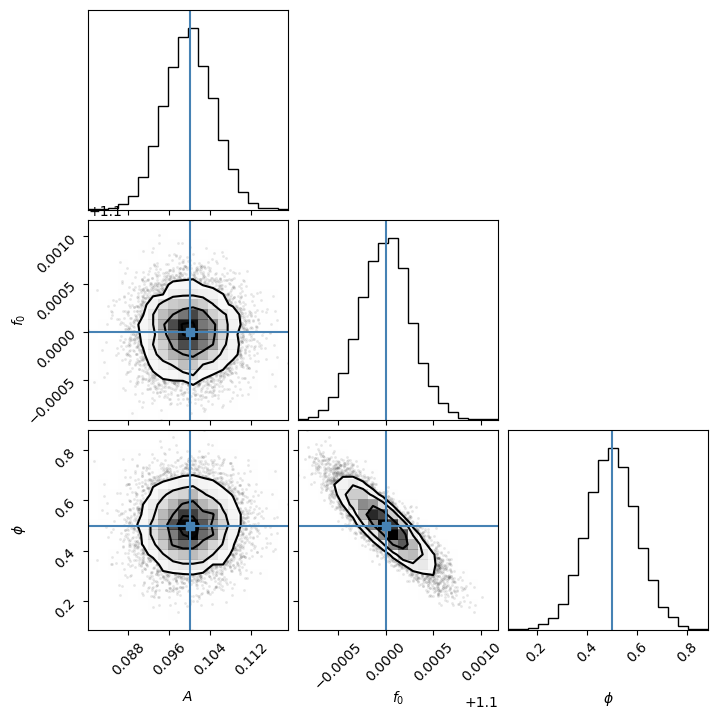

In [53]:
# Parameter inference in frequency domain

# Defining the log likelihood function in frequency domain
def log_prob_f(theta):
    A,f0,phi=theta
    diff = fft(xsin - sinusoid_t(A,f0,phi,Ntry,dttry))
    return -0.5 * np.sum(np.abs(diff)**2/PSD_noise(freqs))

ndim = 3
nwalkers = 32

fidvals = np.array([Atest, f0test, phitest]) # The fiducial values are the ones with which we generated the sinusoid
pos = fidvals + 1e-4 * np.random.randn(nwalkers, ndim) # Initial guess: we take it close to the fiducial values but it does not matter
sampler = emcee.EnsembleSampler(nwalkers,ndim,log_prob_f)

# Running mcmc
sampler.run_mcmc(pos, 3000, progress=True)
samples = sampler.get_chain(discard=100, thin=10, flat=True)

# Plotting mcmc samples
fig = corner.corner(
    samples,
    labels=[r"$A$", r"$f_0$", r"$\phi$"],
    truths=[Atest, f0test, phitest]
)

100%|██████████| 3000/3000 [00:14<00:00, 209.54it/s]


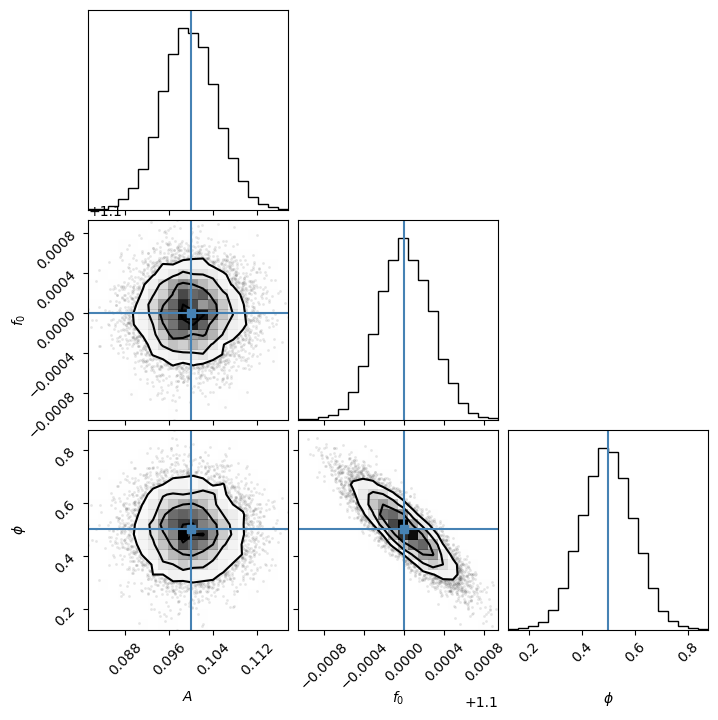

In [54]:
# Parameter inference in wdm domain
# for 1024 long datastream, 3000 mcmc samples it takes about 1 minute

'''
Here it comes an important approximation: we assume that the noise correlations between different n,n' and different m,m' bins are negligible
This is kinda checked in the next cell, but yet has to be thought mathematically...
''' 
# Defining the analytical wdm PSD C_nmn'm'
def CovWnm(n,m,p,q, nt,nf):
    return np.real(np.sum(np.conjugate(gnmf(n,m,larr,nt,nf))*gnmf(p,q,larr,nt,nf)*PSD_noise(larr/Ttry)))

# Precomputing the diagonal part C_nmnm
CovWnm_diag=np.zeros((nttry,nftry+1))
for n in range(nttry):
    for m in range(nftry+1):
        CovWnm_diag[n,m]=CovWnm(n,m,n,m, nttry,nftry)

# Defining the log likelihood function in wdm domain
def log_prob_w(theta):
    A,f0,phi=theta
    diff = xsin_wnm - wdm_forward(sinusoid_t(A,f0,phi,Ntry,dttry), nttry, nftry)
    return -0.5 * np.sum((diff)**2/CovWnm_diag)

ndim = 3
nwalkers = 32

fidvals = np.array([Atest, f0test, phitest]) # The fiducial values are the ones with which we generated the sinusoid
pos = fidvals + 1e-4 * np.random.randn(nwalkers, ndim) # Initial guess: we take it close to the fiducial values but it does not matter


# Running mcmc
from multiprocessing import Pool
with Pool() as pool:
    sampler = emcee.EnsembleSampler(nwalkers,ndim,log_prob_w,pool=pool)
    sampler.run_mcmc(pos, 3000, progress=True)
    samples = sampler.get_chain(discard=100, thin=10, flat=True)


# Plotting mcmc samples
fig = corner.corner(
    samples,
    labels=[r"$A$", r"$f_0$", r"$\phi$"],
    truths=[Atest, f0test, phitest]
)

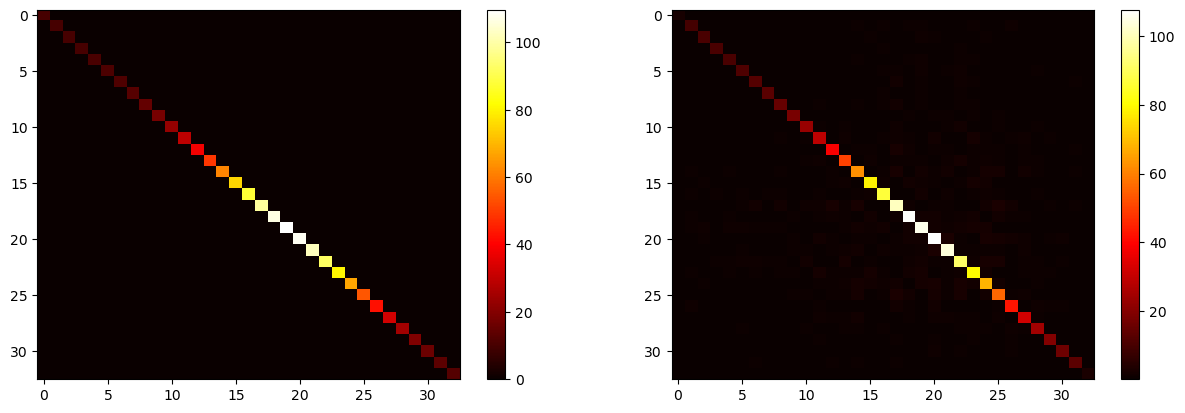

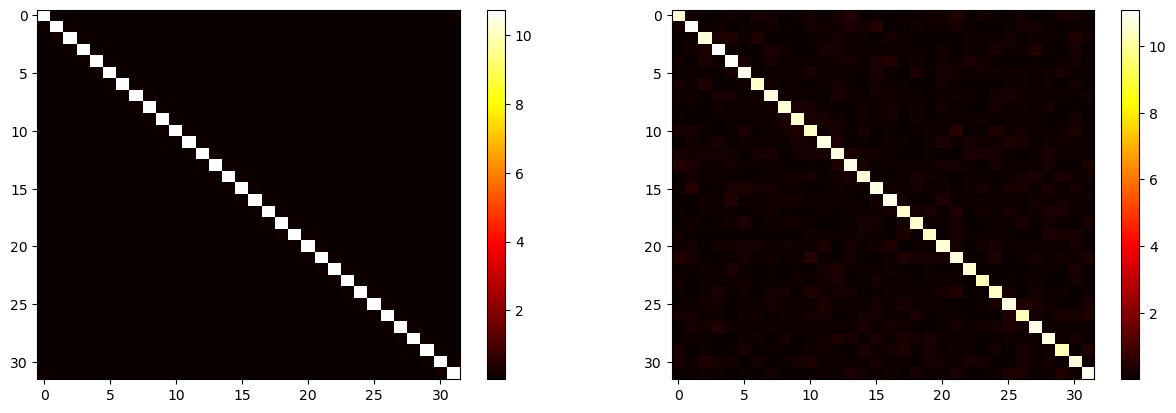

In [55]:
# Generating the covariance matrix C_nmn'm'=<w_nm w_n'm'> averaging many realizations of w_nm
Nmc = 5000
W_accum = np.zeros((nttry, nftry+1, nttry, nftry+1))
for k in range(Nmc):
    xrand = random_signal_f(PSD_noise, Ntry, dttry)
    Wk = wdm_forward(xrand, nttry, nftry)
    W_accum += np.einsum('nm,pq->nmpq', Wk, Wk)
CovWnm_num = W_accum / Nmc

# Computes and plots C_nmnm' for a fixed value of n
mdist_tab_an = np.zeros((nftry+1,nftry+1))
mdist_tab_num = np.zeros((nftry+1,nftry+1))
nfix_test=3
for m in range(nftry+1):
    for m2 in range(nftry+1):
        mdist_tab_an[m,m2]=CovWnm(nfix_test,m,nfix_test,m2,nttry,nftry)
        mdist_tab_num[m,m2]=CovWnm_num[nfix_test,m,nfix_test,m2]

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(15)
im1=ax1.imshow(np.abs(mdist_tab_an), cmap='hot', aspect='auto')
im2=ax2.imshow(np.abs(mdist_tab_num), cmap='hot', aspect='auto')
fig.colorbar(im1, ax=ax1)
fig.colorbar(im2, ax=ax2)
plt.show()

# Computes and plots C_nmn'm for a fixed value of m
ndist_tab_an = np.zeros((nttry,nttry))
ndist_tab_num = np.zeros((nttry,nttry))
mfix_test=5
for n in range(nttry):
    for n2 in range(nttry):
        ndist_tab_an[n,n2]=CovWnm(n,mfix_test,n2,mfix_test,nttry,nftry)
        ndist_tab_num[n,n2]=CovWnm_num[n,mfix_test,n2,mfix_test]

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(15)
im1=ax1.imshow(np.abs(ndist_tab_an), cmap='hot', aspect='auto')
im2=ax2.imshow(np.abs(ndist_tab_num), cmap='hot', aspect='auto')
fig.colorbar(im1, ax=ax1)
fig.colorbar(im2, ax=ax2)
plt.show()

SNR f domain 0.32817173662218674
SNR wdm domain 0.32858013850867224
SNR wdm an domain 0.3325668991633631
SNR f opt 10.50457650227224
SNR w opt 10.687578517016382
SNR w an opt 10.81725408937127


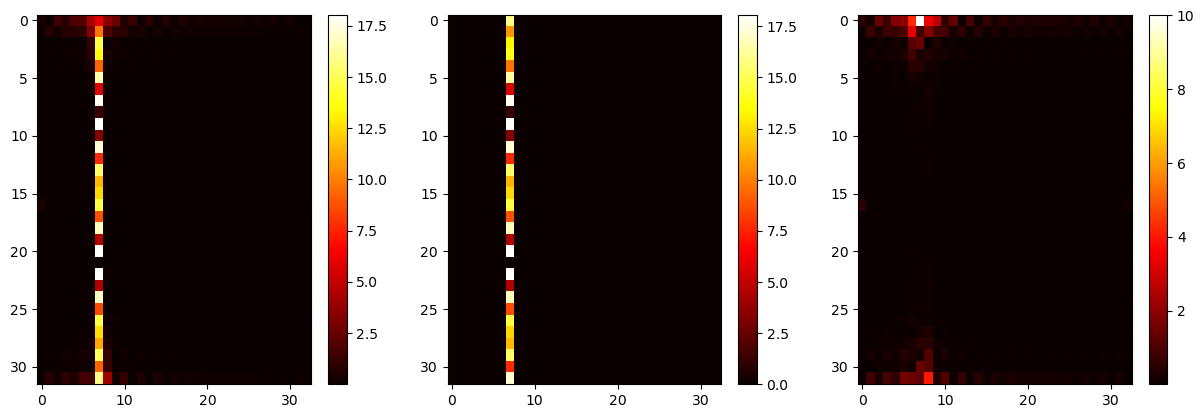

In [56]:
def filterH(l0,n,nt):
    m0=int(2*np.abs(l0)/nt)
    return (np.conj(Cnm(n, m0))*Phi_unit(l0-m0*nt/2,nt)+Cnm(n, m0)*Phi_unit(l0+m0*nt/2,nt))/np.sqrt(2)

def sinusoid_wdm_an(A,f0,phi,dt,nt,nf):
    ntot=nt*nf
    l0=np.abs(f0*ntot*dt)
    W=np.zeros((nt,nf+1))*1j
    narr=np.arange(nt)
    m0=int(2*l0/nt)
    W[:,m0]=A*ntot/(2j) *( np.exp(1j*phi+2j*np.pi*narr*l0/nt)*filterH(l0,narr,nt)
                                     -np.exp(-1j*phi-2j*np.pi*narr*l0/nt)*filterH(-l0,narr,nt) )
    return W


xsin_wnm_an=sinusoid_wdm_an(Atest,f0test,phitest,dttry,nttry,nftry)

SNRsq_w_an = np.real(np.sum(xsin_wnm_an**2) /np.sum(xrand_wnm**2))
print('SNR f domain',np.sqrt(SNRsq_f))
print('SNR wdm domain',np.sqrt(SNRsq_w))
print('SNR wdm an domain',np.sqrt(SNRsq_w_an))

print('SNR f opt',np.sqrt(np.sum(np.abs(xsin_f)**2)/np.var(xrand_f)))
print('SNR w opt',np.sqrt(np.sum(xsin_wnm**2)/np.var(xrand_wnm)))
print('SNR w an opt',np.real(np.sqrt(np.sum(xsin_wnm_an**2)/np.var(xrand_wnm))))


fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.set_figwidth(15)
im1=ax1.imshow(np.abs(xsin_wnm), cmap='hot', aspect='auto')
im2=ax2.imshow(np.abs(xsin_wnm_an), cmap='hot', aspect='auto')
im3=ax3.imshow(np.abs(xsin_wnm-xsin_wnm_an), cmap='hot', aspect='auto')
fig.colorbar(im1, ax=ax1)
fig.colorbar(im2, ax=ax2)
fig.colorbar(im3, ax=ax3)
plt.show()


/home/giorgio/miniconda3/lib/python3.13/site-packages/emcee/ensemble.py:713: ComplexWarning: Casting complex values to real discards the imaginary part
  return float(fx)
100%|██████████| 3000/3000 [00:05<00:00, 585.47it/s]


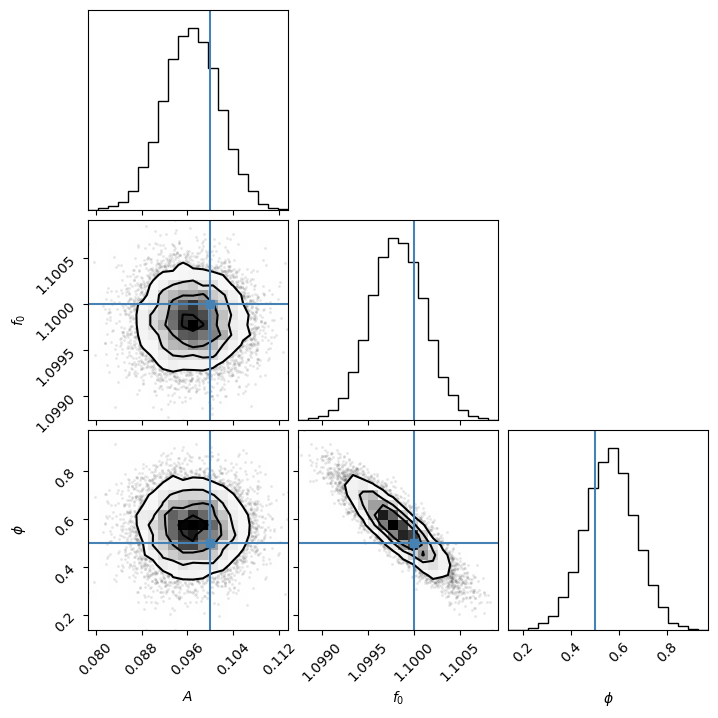

In [57]:
def log_prob_w_an(theta):
    A,f0,phi=theta
    l0=np.abs(f0*Ntry*dttry)
    m0=int(2*l0/nttry)
    diff = xsin_wnm[:,m0] - sinusoid_wdm_an(A,f0,phi,dttry,nttry,nftry)[:,m0]
    return -0.5 * np.sum((diff)**2/CovWnm_diag[:,m0])

ndim = 3
nwalkers = 32

fidvals = np.array([Atest, f0test, phitest]) # The fiducial values are the ones with which we generated the sinusoid
pos = fidvals + 1e-4 * np.random.randn(nwalkers, ndim) # Initial guess: we take it close to the fiducial values but it does not matter

# Running mcmc
from multiprocessing import Pool
with Pool() as pool:
    sampler = emcee.EnsembleSampler(nwalkers,ndim,log_prob_w_an,pool=pool)
    sampler.run_mcmc(pos, 3000, progress=True)
    samples = sampler.get_chain(discard=100, thin=10, flat=True)


# Plotting mcmc samples
fig = corner.corner(
    samples,
    labels=[r"$A$", r"$f_0$", r"$\phi$"],
    truths=[Atest, f0test, phitest]
)

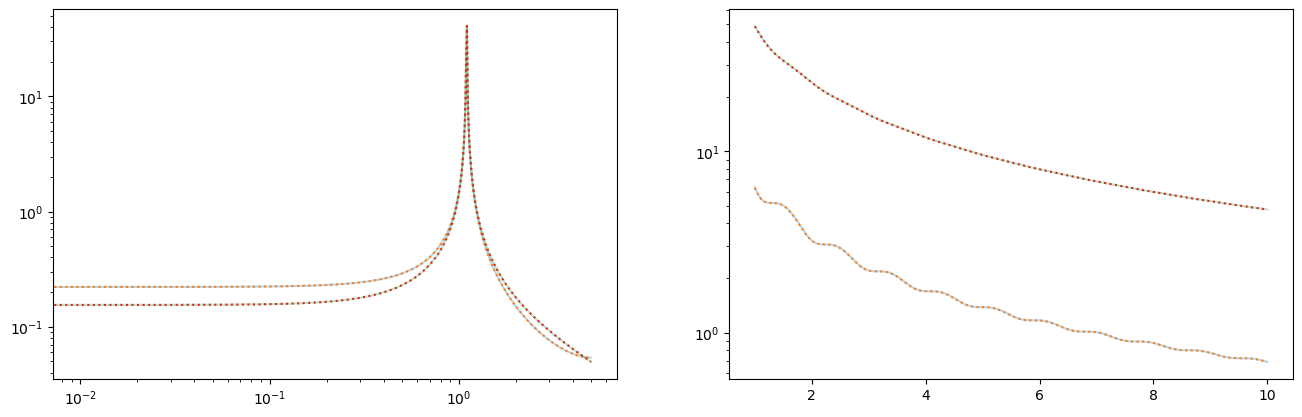

In [107]:
def sincspec(f,T):
    return (np.exp(-2j*np.pi*f*T)-1)/f

def sincspec1(f,T):
    return (1-2j*np.pi*T*f*np.exp(-2j*np.pi*f*T)-np.exp(-2j*np.pi*f*T))/(f**2)

def sincspec2(f,T):
    return -(2+4*np.pi**2*T**2*f**2*np.exp(-2j*np.pi*f*T)-4j*np.pi*T*f*np.exp(-2j*np.pi*f*T)-2*np.exp(-2j*np.pi*f*T))/(f**3)

def sinusoid_f2(A,f0,phi,N,dt):
    l=fftfreq(N)*N
    l0=f0*N*dt
    term1=(np.exp(-2j*np.pi*(l-l0))-1)/(l-l0)
    term2=(np.exp(-2j*np.pi*(l+l0))-1)/(l+l0)
    return (A/4/np.pi)*N*(np.exp(1j*phi)*term1-np.exp(-1j*phi)*term2)

def sinusoid_f3(A,f0,phi,N,dt):
    f=fftfreq(N,dt)
    term1=sincspec(f-f0,N*dt)
    term2=sincspec(f+f0,N*dt)
    return (A/4/np.pi)*(np.exp(1j*phi)*term1-np.exp(-1j*phi)*term2)/dt



xsin_f1=sinusoid_f(Atest,f0test,phitest,Ntry,dttry)
xsin_f2=sinusoid_f2(Atest,f0test,phitest,Ntry,dttry)
xsin_f3=sinusoid_f3(Atest,f0test,phitest,Ntry,dttry)

farrrtry=np.linspace(1,10,1000)
Tttttt=1.1
sincspec1num=[]
sincspec2num=[]
for i in range(len(farrrtry)-1):
    sincspec1num.append((sincspec(farrrtry[i+1],Tttttt)-sincspec(farrrtry[i],Tttttt))/(farrrtry[i+1]-farrrtry[i]))
    sincspec2num.append((sincspec1(farrrtry[i+1],Tttttt)-sincspec1(farrrtry[i],Tttttt))/(farrrtry[i+1]-farrrtry[i]))

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(16)
ax1.loglog(freqs[idx],np.abs(xsin_f[idx]),alpha=0.3)
ax1.loglog(freqs[idx],np.abs(xsin_f1[idx]),linestyle='dotted')
ax1.loglog(freqs[idx],np.abs(xsin_f2[idx]),alpha=0.3)
ax1.loglog(freqs[idx],np.abs(xsin_f3[idx]),linestyle='dotted')

ax2.semilogy(farrrtry,np.abs(sincspec1(farrrtry,Tttttt)),alpha=0.3)
ax2.semilogy(farrrtry[:-1],np.abs(np.array(sincspec1num)),linestyle='dotted')
ax2.semilogy(farrrtry,np.abs(sincspec2(farrrtry,Tttttt)),alpha=0.3)
ax2.semilogy(farrrtry[:-1],np.abs(np.array(sincspec2num)),linestyle='dotted')

plt.show()

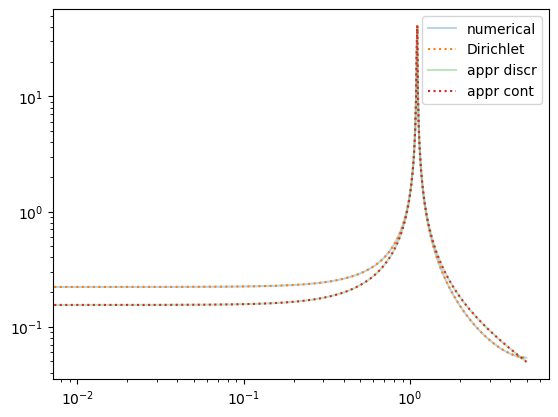

In [119]:
def sinusoid_t(A,f0,phi,N,dt): # Generate signal at our sampled times
    t = np.arange(N) * dt
    return A * np.sin(2 * np.pi * f0 * t + phi)

def dirichlet(l,N):
    return np.sin(np.pi*l)/np.sin(np.pi*l/N)

def sinusoid_f(A,f0,phi,N,dt):
    l=fftfreq(N)*N
    l0=f0*N*dt
    exp1=np.exp(1j*phi+1j*np.pi*(l0-l)*(N-1)/N)
    exp2=np.exp(-1j*phi-1j*np.pi*(l0+l)*(N-1)/N)
    return (A/2j)*(exp1*dirichlet(l0-l,N)-exp2*dirichlet(l0+l,N))

def sincspec(f,T):
    return (np.exp(-2j*np.pi*f*T)-1)/f

def sincspec1(f,T):
    return (1-2j*np.pi*T*f*np.exp(-2j*np.pi*f*T)-np.exp(-2j*np.pi*f*T))/(f**2)

def sincspec2(f,T):
    return -(2+4*np.pi**2*T**2*f**2*np.exp(-2j*np.pi*f*T)-4j*np.pi*T*f*np.exp(-2j*np.pi*f*T)-2*np.exp(-2j*np.pi*f*T))/(f**3)

def sinusoid_f2(A,f0,phi,N,dt):
    l=fftfreq(N)*N
    l0=f0*N*dt
    term1=(np.exp(-2j*np.pi*(l-l0))-1)/(l-l0)
    term2=(np.exp(-2j*np.pi*(l+l0))-1)/(l+l0)
    return (A/4/np.pi)*N*(np.exp(1j*phi)*term1-np.exp(-1j*phi)*term2)

def sinusoid_f3(A,f0,phi,N,dt):
    f=fftfreq(N,dt)
    term1=sincspec(f-f0,N*dt)
    term2=sincspec(f+f0,N*dt)
    return (A/4/np.pi)*(np.exp(1j*phi)*term1-np.exp(-1j*phi)*term2)/dt

def chirp_t(A,f0,phi,a,N,dt):
    t = np.arange(N) * dt
    return A * np.sin(2 * np.pi * f0 * t + phi + a * t**2)

def chirp_f(A,f0,phi,a,N,dt):
    f=fftfreq(N,dt)
    term1dd = np.exp(1j*(phi+np.pi/2))*sincspec2(f-f0,N*dt)
    term2dd = np.exp(-1j*(phi+np.pi/2))*sincspec2(f+f0,N*dt)
    return sinusoid_f3(A,f0,phi,N,dt) -(a/(2*np.pi)**2)*(A/4/np.pi)*(term1dd-term2dd)*dt


Ntry=1024
dttry=1e-1
atest=0.0001

Atest=0.1
f0test=1.1
phitest=0.5

times=np.arange(Ntry)*dttry
Ttry=Ntry*dttry
freqs=fftfreq(Ntry,dttry)
idx = np.argsort(freqs)

xsin=sinusoid_t(Atest,f0test,phitest,Ntry,dttry)
xsin_fnum=fft(xsin)
xsin_f1=sinusoid_f(Atest,f0test,phitest,Ntry,dttry)
xsin_f2=sinusoid_f2(Atest,f0test,phitest,Ntry,dttry)
xsin_f3=sinusoid_f3(Atest,f0test,phitest,Ntry,dttry)

xchirp=chirp_t(Atest,f0test,phitest,atest,Ntry,dttry)
xchirp_f_num=fft(xchirp)
xchirp_f=chirp_f(Atest,f0test,phitest,atest,Ntry,dttry)

#plt.plot(freqs[idx],np.abs(xchirp_f_num[idx]),alpha=0.3)
plt.loglog(freqs[idx],np.abs(xsin_fnum[idx]),alpha=0.3,label='numerical')
plt.loglog(freqs[idx],np.abs(xsin_f[idx]),linestyle='dotted',label='Dirichlet')
plt.loglog(freqs[idx],np.abs(xsin_f2[idx]),alpha=0.3,label='appr discr')
plt.loglog(freqs[idx],np.abs(xsin_f3[idx]),linestyle='dotted',label='appr cont')
#plt.plot(freqs[idx],np.abs(xchirp_f[idx]),linestyle='dotted')
#plt.xlim(1,1.5)
plt.legend()
plt.show()

In [95]:
Atest

0.1